<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/Copia_de_Anomalias3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El fraude no solo cuesta dinero, sino también confianza. Como miembro clave de un equipo de cumplimiento financiero, su misión es descubrir transacciones sospechosas que, de otro modo, podrían pasar desapercibidas. Con tanto en juego, sus conocimientos podrían marcar la diferencia entre detener el fraude de raíz o evitar que pase desapercibido.

En este proyecto, aprovechará el poder de todo lo que aprendió en su clase de minería de datos para detectar anomalías. Su reto: identificar transacciones inusuales, resumir sus hallazgos y proporcionar información práctica que garantice la confianza, la seguridad y la eficiencia en las operaciones financieras.

Trabajará con un conjunto de datos en el archivo `transactions.csv` que contiene información sobre transacciones financieras. A continuación, se muestra un resumen de las columnas clave proporcionadas:

| **Columna** | **Descripción** |
|--------------------------|---------------------------------------------------------------------------------------------------|
| `TransactionID` | Un identificador único para cada transacción. |
| `TransactionAmount` | La cantidad de dinero involucrada en la transacción (en USD). |
| `TransactionDuration` | Duración de la transacción (en segundos). |
| `AccountBalance` | El saldo de la cuenta después de procesar la transacción (en USD). |

### Instrucciones

1. Para cada una de las tres columnas importantes, realizar un análisis e identificar las transacciones anómalas.
2. Identificar las transacciones que presentan anomalías en las tresa columnas simultáneamente.
3. Contestar. ¿Cuántas transacciones presentan anomalías en tres columnas al mismo tiempo?
4. Contestar. ¿Cuántas transacciones presentan anomalías en dos columnas al mismo tiempo?


In [ ]:
import pandas as pd

transacciones = pd.read_csv("transactions.csv")
cantidad = transacciones['TransactionAmount']
duracion = transacciones['TransactionDuration']
saldo = transacciones['AccountBalance']

Text(0.5, 0, 'Saldo')

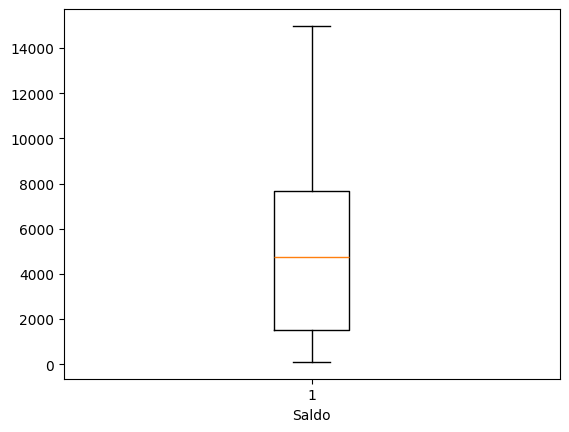

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(saldo)
plt.xlabel("Saldo")



Text(0.5, 0, 'Duración')

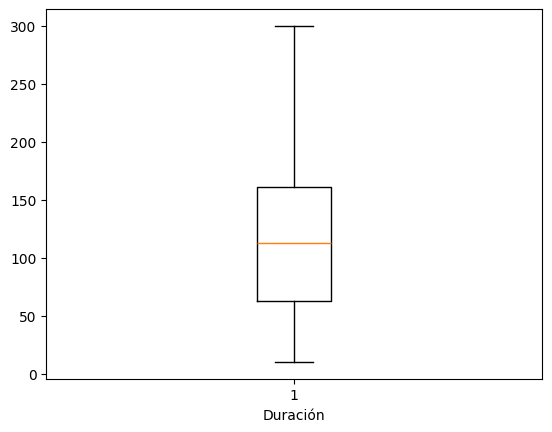

In [ ]:
plt.boxplot(duracion)
plt.xlabel("Duración")



Text(0.5, 0, 'Cantidad')

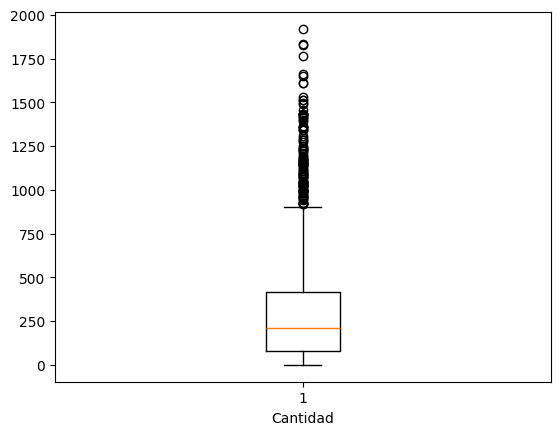

In [ ]:
plt.boxplot(cantidad)
plt.xlabel("Cantidad")


In [ ]:
# Calcular cuartiles de cantidad
q1 = cantidad.quantile(0.25)
q3 = cantidad.quantile(0.75)

# Calcular IQR
IQR = q3 - q1

# Factor del IQR
factor = 2.5

limite_inferior = q1 - (IQR * factor)
limite_superior = q3 + (IQR * factor)

In [ ]:
# Calcular cuartiles de saldo
q1 = saldo.quantile(0.25)
q3 = saldo.quantile(0.75)

# Calcular IQR
IQR = q3 - q1

# Factor del IQR
factor = 2.5

limite_inferior = q1 - (IQR * factor)
limite_superior = q3 + (IQR * factor)

In [ ]:
# Calcular cuartiles de duracion
q1 = duracion.quantile(0.25)
q3 = duracion.quantile(0.75)

# Calcular IQR
IQR = q3 - q1

# Factor del IQR
factor = 2.5

limite_inferior = q1 - (IQR * factor)
limite_superior = q3 + (IQR * factor)

In [ ]:
# Podemos crear máscaras para filtrar los datos anómalos
es_menor = duracion < limite_inferior
es_mayor = duracion > limite_superior

# Filter
outliers = duracion[es_menor | es_mayor]

#Cantidad de datos anómalos
print(len(outliers))

0


In [ ]:
# Podemos crear máscaras para filtrar los datos anómalos
es_menor = cantidad < limite_inferior
es_mayor = cantidad > limite_superior

# Filter
outliers = cantidad[es_menor | es_mayor]

#Cantidad de datos anómalos
print(len(outliers))

647


In [ ]:
# Podemos crear máscaras para filtrar los datos anómalos
es_menor = saldo < limite_inferior
es_mayor = saldo > limite_superior

# Filter
outliers = saldo[es_menor | es_mayor]

#Cantidad de datos anómalos
print(len(outliers))

2382



Estadísticas básicas (todos los datos):
count    2512.00
mean      297.59
std       291.95
min         0.26
25%        81.89
50%       211.14
75%       414.53
max      1919.11
Name: TransactionAmount, dtype: float64

ANOMALÍAS POR cantidad INVÁLIDO (<= $0)
  Registros con cantidad <= 0 : 0
  % del total               : 0.0000%

  Registros válidos (cantidad > 0): 2,512

Q1  = $81.89
Q3  = $414.53
IQR = $332.64

FACTOR 1.5  (Tukey estándar)
  Límite inferior IQR : $-84.44
  Límite superior IQR : $913.49
  cantidades altas   : 113
  cantidades inválidas   : 0
  Total anomalías     : 113  (4.50%)

FACTOR 3  (método clase)
  Límite inferior IQR : $-84.44
  Límite superior IQR : $1412.46
  cantidades altas   : 22
  cantidades inválidas   : 0
  Total anomalías     : 22  (0.88%)

DIFERENCIA entre métodos: 91 cantidades
(cantidades altas adicionales con factor 1.5)


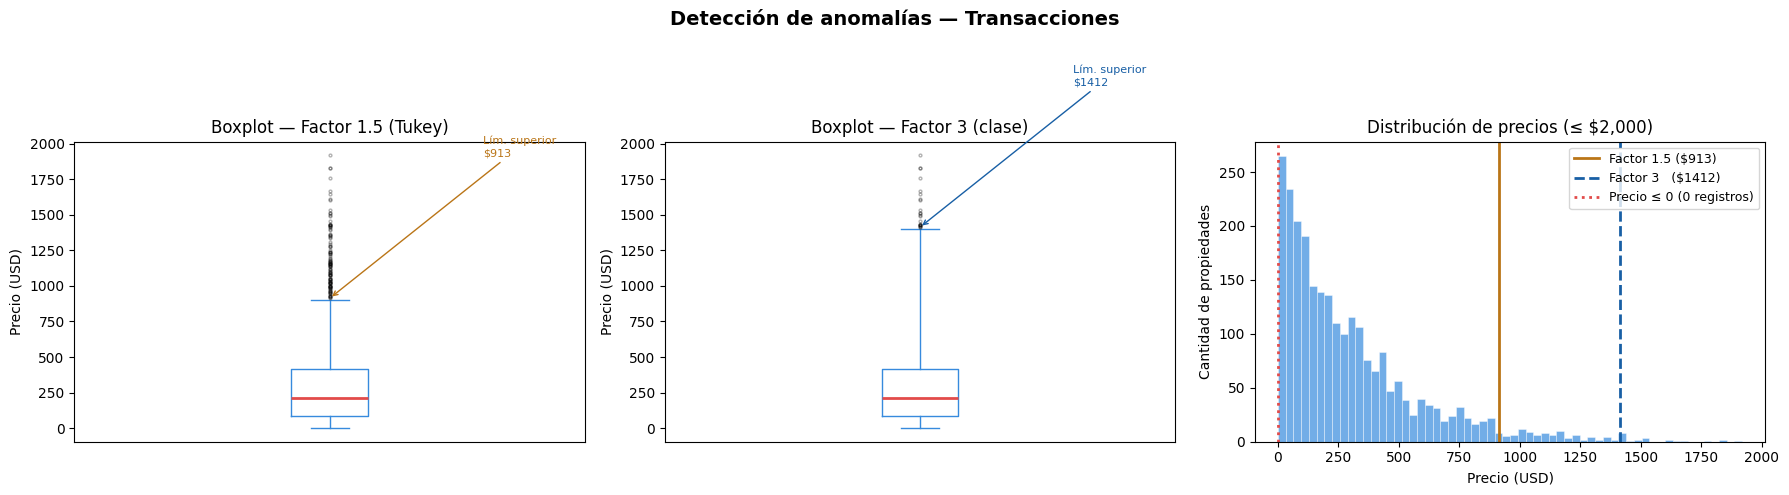


               Tipo de anomalía            Criterio  Cantidad % del total
      cantidad inválido (≤ $0)       cantidad <= 0         0     0.0000%
Cantidad muy alto — Factor 1.5  cantidad > $913.49       113       4.50%
  cantidad muy alto — Factor 3 cantidad > $1412.46        22       0.88%


In [ ]:
# ============================================================
# DETECCIÓN DE ANOMALÍAS — Transacciones
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Cargar datos ──────────────────────────────────────────
df = pd.read_csv("transactions.csv", low_memory=False)

print(f"\nEstadísticas básicas (todos los datos):")
print(cantidad.describe().round(2))


# ── 2. Detectar precios anomalos <= 0 ───────────────────────
precios_invalidos = cantidad[cantidad <= 0]

print(f"\n{'='*45}")
print(f"ANOMALÍAS POR cantidad INVÁLIDO (<= $0)")
print(f"{'='*45}")
print(f"  Registros con cantidad <= 0 : {len(precios_invalidos):,}")
print(f"  % del total               : {len(precios_invalidos)/len(cantidad)*100:.4f}%")
if len(precios_invalidos) > 0:
    print(f"  Valores únicos encontrados: {sorted(precios_invalidos.unique())}")

# Separar los datos válidos para el análisis IQR
precios = cantidad[cantidad > 0]
print(f"\n  Registros válidos (cantidad > 0): {len(precios):,}")


# ── 3. Calcular IQR y límites ────────────────────────────────
q1 = precios.quantile(0.25)
q3 = precios.quantile(0.75)
IQR = q3 - q1

print(f"\nQ1  = ${q1:.2f}")
print(f"Q3  = ${q3:.2f}")
print(f"IQR = ${IQR:.2f}")


# ── 4. Método 1 — Factor 1.5 (Tukey estándar) ───────────────
factor_1 = 1.5
li_1 = q1 - IQR * .5
ls_1 = q3 + IQR * factor_1

outliers_altos_1 = precios[precios > ls_1]
outliers_total_1 = len(outliers_altos_1) + len(precios_invalidos)

print(f"\n{'='*45}")
print(f"FACTOR 1.5  (Tukey estándar)")
print(f"{'='*45}")
print(f"  Límite inferior IQR : ${li_1:.2f}")
print(f"  Límite superior IQR : ${ls_1:.2f}")
print(f"  cantidades altas   : {len(outliers_altos_1):,}")
print(f"  cantidades inválidas   : {len(precios_invalidos):,}")
print(f"  Total anomalías     : {outliers_total_1:,}  ({outliers_total_1/len(cantidad)*100:.2f}%)")


# ── 5. Método 2 — Factor 3 (método clase) ───────────────────
factor_2 = 3
li_2 = q1 - IQR * .5
ls_2 = q3 + IQR * factor_2

outliers_altos_2 = precios[precios > ls_2]
outliers_total_2 = len(outliers_altos_2) + len(precios_invalidos)

print(f"\n{'='*45}")
print(f"FACTOR 3  (método clase)")
print(f"{'='*45}")
print(f"  Límite inferior IQR : ${li_2:.2f}")
print(f"  Límite superior IQR : ${ls_2:.2f}")
print(f"  cantidades altas   : {len(outliers_altos_2):,}")
print(f"  cantidades inválidas   : {len(precios_invalidos):,}")
print(f"  Total anomalías     : {outliers_total_2:,}  ({outliers_total_2/len(cantidad)*100:.2f}%)")


# ── 6. Comparación ───────────────────────────────────────────
diferencia = len(outliers_altos_1) - len(outliers_altos_2)
print(f"\n{'='*45}")
print(f"DIFERENCIA entre métodos: {diferencia:,} cantidades")
print(f"(cantidades altas adicionales con factor 1.5)")


# ── 7. Visualizaciones ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Detección de anomalías — Transacciones", fontsize=14, fontweight="bold")

# --- Boxplot con factor 1.5 ---
axes[0].boxplot(precios, whis=1.5, vert=True,
                boxprops=dict(color="#378ADD"),
                medianprops=dict(color="#E24B4A", linewidth=2),
                whiskerprops=dict(color="#378ADD"),
                capprops=dict(color="#378ADD"),
                flierprops=dict(marker="o", color="#BA7517", alpha=0.3, markersize=2))
axes[0].set_title("Boxplot — Factor 1.5 (Tukey)")
axes[0].set_ylabel("Precio (USD)")
axes[0].set_xticks([])
axes[0].annotate(f"Lím. superior\n${ls_1:.0f}",
                 xy=(1, ls_1), xytext=(1.3, ls_1 + 1000),
                 fontsize=8, color="#BA7517",
                 arrowprops=dict(arrowstyle="->", color="#BA7517"))

# --- Boxplot con factor 3 ---
axes[1].boxplot(precios, whis=3, vert=True,
                boxprops=dict(color="#378ADD"),
                medianprops=dict(color="#E24B4A", linewidth=2),
                whiskerprops=dict(color="#378ADD"),
                capprops=dict(color="#378ADD"),
                flierprops=dict(marker="o", color="#185FA5", alpha=0.3, markersize=2))
axes[1].set_title("Boxplot — Factor 3 (clase)")
axes[1].set_ylabel("Precio (USD)")
axes[1].set_xticks([])
axes[1].annotate(f"Lím. superior\n${ls_2:.0f}",
                 xy=(1, ls_2), xytext=(1.3, ls_2 + 1000),
                 fontsize=8, color="#185FA5",
                 arrowprops=dict(arrowstyle="->", color="#185FA5"))

# --- Histograma comparativo ---
precios_clip = precios[precios <= 2000]
axes[2].hist(precios_clip, bins=60, color="#378ADD", alpha=0.7, edgecolor="white", linewidth=0.4)
axes[2].axvline(ls_1, color="#BA7517", linewidth=2, linestyle="-",  label=f"Factor 1.5 (${ls_1:.0f})")
axes[2].axvline(ls_2, color="#185FA5", linewidth=2, linestyle="--", label=f"Factor 3   (${ls_2:.0f})")
axes[2].axvline(0,    color="#E24B4A", linewidth=2, linestyle=":",  label=f"Precio ≤ 0 ({len(precios_invalidos):,} registros)")
axes[2].set_title("Distribución de precios (≤ $2,000)")
axes[2].set_xlabel("Precio (USD)")
axes[2].set_ylabel("Cantidad de propiedades")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ── 8. Tabla resumen final ───────────────────────────────────
resumen = pd.DataFrame({
    "Tipo de anomalía":  ["cantidad inválido (≤ $0)",
                          "Cantidad muy alto — Factor 1.5",
                          "cantidad muy alto — Factor 3"],
    "Criterio":          ["cantidad <= 0",
                          f"cantidad > ${ls_1:.2f}",
                          f"cantidad > ${ls_2:.2f}"],
    "Cantidad":          [len(precios_invalidos),
                          len(outliers_altos_1),
                          len(outliers_altos_2)],
    "% del total":       [f"{len(precios_invalidos)/len(cantidad)*100:.4f}%",
                          f"{len(outliers_altos_1)/len(cantidad)*100:.2f}%",
                          f"{len(outliers_altos_2)/len(cantidad)*100:.2f}%"],
})
print("\n", resumen.to_string(index=False))